# M3: Morgan Baseline - Random Split vs Scaffold Split

Goal: keep the same Morgan fingerprint and the same RandomForest / XGBoost models from M2, then compare two data splits:

- **random split**: sklearn `train_test_split`, same seed as M2;
- **scaffold split**: molecules grouped by Murcko scaffold, with whole scaffolds kept together.

The scaffold split is the harder test: the model has to predict molecules whose scaffold was never seen during training.


In [1]:
from pathlib import Path

import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load the M1 dataset

Each row is one unique standardized molecule; `pIC50` is the regression target.


In [2]:
final_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "egfr_activity_final.csv")
print(f"molecules: {len(final_df):,}")
print(f"pIC50 range: {final_df['pIC50'].min():.2f} - {final_df['pIC50'].max():.2f}")

molecules: 10,161
pIC50 range: 1.60 - 11.52


## 2. Same Morgan representation as M2

SMILES -> RDKit Mol -> Morgan fingerprint (radius 2, 2048 bits) -> numeric feature matrix `X`.

Morgan fingerprint is a fixed rule-based representation, not a learned embedding.


In [3]:
def smiles_to_fp(smiles: str, radius: int = 2, n_bits: int = 2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    generator = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = generator.GetFingerprint(mol)
    return np.array(list(fp), dtype=np.float32)

X = np.vstack(final_df["canonical_smiles"].map(smiles_to_fp).to_numpy())
y = final_df["pIC50"].to_numpy(dtype=np.float32)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (10161, 2048)
y shape: (10161,)


## 3. Two split strategies

- Random split: `train_test_split(test_size=0.2, random_state=42)`.
- Scaffold split: group by Murcko scaffold, keep scaffolds intact, and greedily fill the train side to about 80%.

This cell also prints the scaffold size distribution and train/test pIC50 distribution, which matter when interpreting the results.


In [4]:
def scaffold_split_indices(smiles, test_size=0.2):
    groups = {}
    for idx, smi in enumerate(smiles):
        mol = Chem.MolFromSmiles(smi)
        scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
        groups.setdefault(scaffold, []).append(idx)
    ordered = sorted(groups.items(), key=lambda item: (-len(item[1]), item[0]))
    train_cutoff = int((1 - test_size) * len(smiles))
    train_idx, test_idx = [], []
    for _, indices in ordered:
        if len(train_idx) + len(indices) <= train_cutoff:
            train_idx.extend(indices)
        else:
            test_idx.extend(indices)
    train_set = set(train_idx)
    train_sizes = [
        len(indices)
        for _, indices in ordered
        if all(i in train_set for i in indices)
    ]
    test_sizes = [
        len(indices)
        for _, indices in ordered
        if not all(i in train_set for i in indices)
    ]
    return train_idx, test_idx, len(ordered), train_sizes, test_sizes

def size_summary(sizes):
    arr = np.asarray(sizes, dtype=float)
    if len(arr) == 0:
        return {"count": 0, "min": None, "max": None, "mean": None, "singletons": 0}
    return {
        "count": int(len(arr)),
        "min": float(arr.min()),
        "max": float(arr.max()),
        "mean": float(arr.mean()),
        "singletons": int((arr == 1).sum()),
    }

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, random_state=42
)
train_idx, test_idx, n_scaffolds, train_sizes, test_sizes = scaffold_split_indices(
    final_df["canonical_smiles"].tolist(), test_size=0.2
)
X_train_s, X_test_s = X[train_idx], X[test_idx]
y_train_s, y_test_s = y[train_idx], y[test_idx]

print(f"random split   train={len(y_train_r):,}  test={len(y_test_r):,}")
print(f"scaffold split train={len(y_train_s):,}  test={len(y_test_s):,}")
print(f"unique scaffolds: {n_scaffolds:,}")
print("scaffold size summary train:", size_summary(train_sizes))
print("scaffold size summary test:", size_summary(test_sizes))
print(f"pIC50 mean random   train/test: {y_train_r.mean():.3f} / {y_test_r.mean():.3f}")
print(f"pIC50 mean scaffold train/test: {y_train_s.mean():.3f} / {y_test_s.mean():.3f}")

random split   train=8,128  test=2,033
scaffold split train=8,128  test=2,033
unique scaffolds: 3,641
scaffold size summary train: {'count': 1608, 'min': 1.0, 'max': 560.0, 'mean': 5.054726368159204, 'singletons': 365}
scaffold size summary test: {'count': 2033, 'min': 1.0, 'max': 1.0, 'mean': 1.0, 'singletons': 2033}
pIC50 mean random   train/test: 6.948 / 6.921
pIC50 mean scaffold train/test: 7.010 / 6.676


## 4. Same models for both splits

RandomForest and XGBoost use the same hyperparameters as M2. Fresh model instances are created for each split so the two comparisons are independent.


In [5]:
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
        "Pearson_r": pearsonr(y_true, y_pred)[0],
        "Spearman_rho": spearmanr(y_true, y_pred)[0],
    }

def make_models(seed=42):
    return {
        "RandomForest": RandomForestRegressor(n_estimators=300, random_state=seed, n_jobs=-1),
        "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=seed, n_jobs=-1, verbosity=0),
    }

splits = {
    "random": (X_train_r, y_train_r, X_test_r, y_test_r),
    "scaffold": (X_train_s, y_train_s, X_test_s, y_test_s),
}
metrics = {name: {} for name in splits}
for split_name, (X_tr, y_tr, X_te, y_te) in splits.items():
    for model_name, model in make_models().items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        metrics[split_name][model_name] = evaluate(y_te, y_pred)
print("training done")

training done


## 5. Compare test-set metrics

`R2` and `RMSE` are the two headline metrics. A drop from random to scaffold split is expected and is not a bug; it shows how much performance depended on seeing similar scaffolds in training.


In [6]:
print("Test-set metrics by split:")
for split_name in ["random", "scaffold"]:
    print(f"\n{split_name}:")
    for model_name, metric in metrics[split_name].items():
        print(f"  {model_name}:")
        for key, value in metric.items():
            print(f"    {key}: {value:.4f}")

Test-set metrics by split:

random:
  RandomForest:
    MAE: 0.5361
    RMSE: 0.7379
    R2: 0.7010
    Pearson_r: 0.8378
    Spearman_rho: 0.8370
  XGBoost:
    MAE: 0.6236
    RMSE: 0.8163
    R2: 0.6340
    Pearson_r: 0.7987
    Spearman_rho: 0.8027

scaffold:
  RandomForest:
    MAE: 0.7588
    RMSE: 0.9985
    R2: 0.3977
    Pearson_r: 0.6559
    Spearman_rho: 0.6509
  XGBoost:
    MAE: 0.8116
    RMSE: 1.0581
    R2: 0.3237
    Pearson_r: 0.6005
    Spearman_rho: 0.6049


## 6. Reproducibility check against the M3 script

The script `src/models/evaluate_splits.py` saves
`results/m3_morgan_split_comparison_results.json`. This cell verifies that the
notebook and the script produced identical metrics.


In [7]:
saved_path = RESULTS_DIR / "m3_morgan_split_comparison_results.json"
if saved_path.exists():
    saved = json.loads(saved_path.read_text())
    matches = (
        saved["splits"]["random"]["metrics"] == metrics["random"]
        and saved["splits"]["scaffold"]["metrics"] == metrics["scaffold"]
    )
    print("notebook metrics match saved JSON:", matches)
    if not matches:
        raise ValueError("Notebook metrics differ from src/models/evaluate_splits.py JSON")
else:
    print("saved JSON not found; run src/models/evaluate_splits.py first")

notebook metrics match saved JSON: True


## 7. Comparison figure

The grouped bars make it easy to see the random-to-scaffold drop for both models.


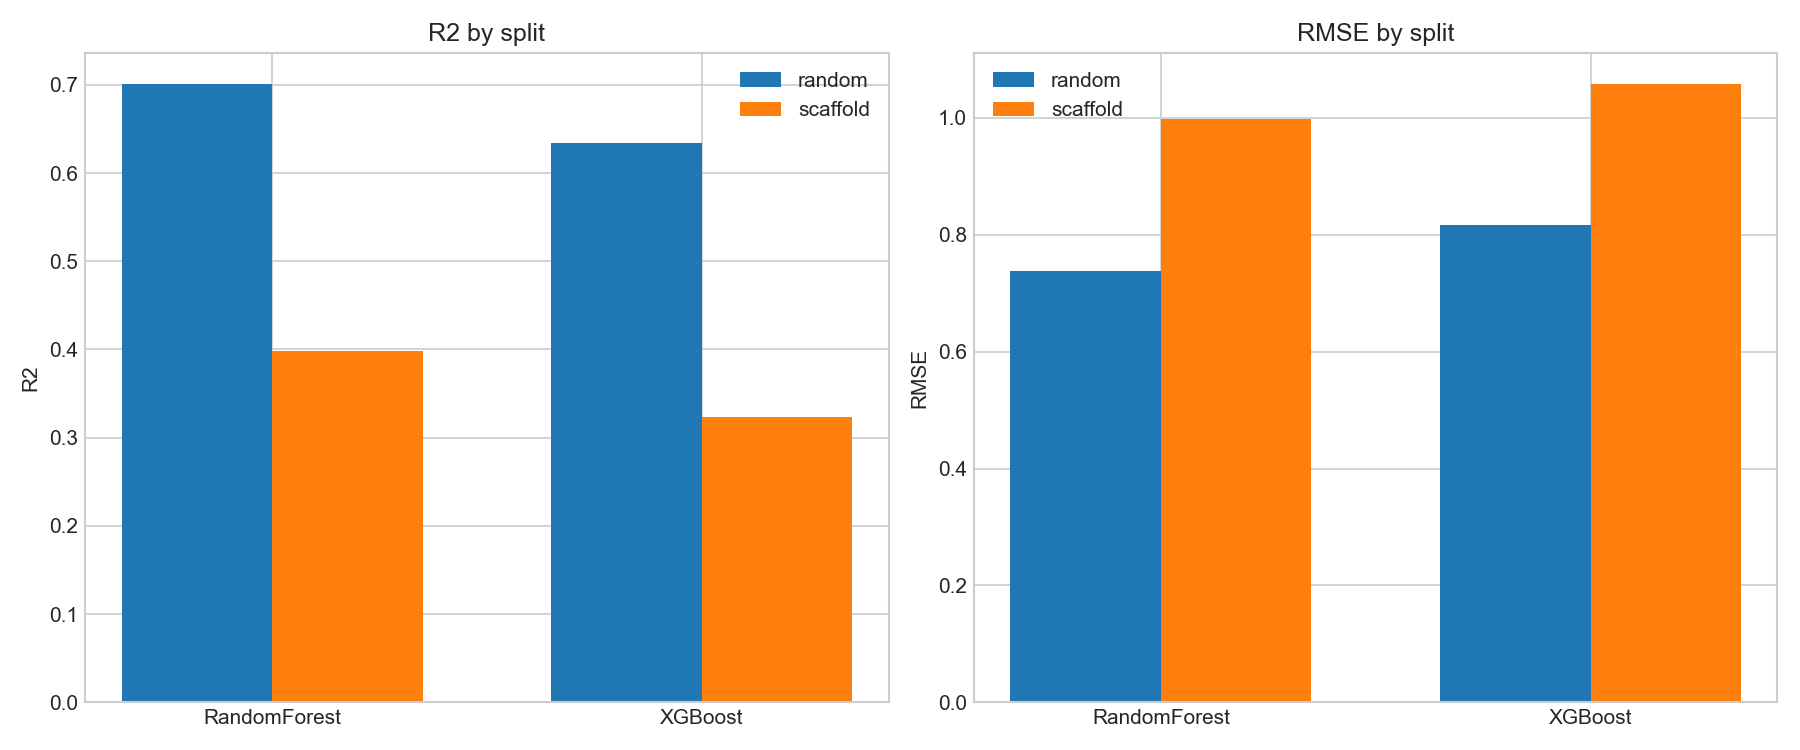

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model_names = ["RandomForest", "XGBoost"]
split_names = ["random", "scaffold"]
x = np.arange(len(model_names))
width = 0.35
for ax, metric_name in zip(axes, ["R2", "RMSE"]):
    for j, split_name in enumerate(split_names):
        values = [metrics[split_name][model][metric_name] for model in model_names]
        ax.bar(x + (j - 0.5) * width, values, width, label=split_name)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} by split")
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "m3_random_vs_scaffold_split.png", dpi=150)
plt.show()

## 8. How to interpret the results

1. The random split is the optimistic reference: similar molecules appear in both train and test.
2. The scaffold split is the harder, more realistic estimate of generalization to new chemistry.
3. **Boundary of the current scaffold split**: in this dataset the test scaffolds are all singletons, so M3 tests extreme "unseen scaffold" extrapolation. A scaffold-balanced split would be needed to test within-scaffold SAR.
4. **Label shift**: the scaffold test set has a lower mean pIC50 than the train set, so part of the R2 drop comes from the test labels being distributed differently, not only from chemistry being harder.
5. Keep both numbers in the report: M2 gives the optimistic baseline, M3 gives the new-chemistry estimate.
